# Imports và Cấu hình (Configuration)

In [1]:
import os
import math
import random
from collections import deque

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Custom imports
from Bert4Rec_model import BERT4Rec, gather_indexes

# Cấu hình môi trường và đường dẫn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' 
os.environ['TORCH_USE_CUDA_DSA'] = '1'

RATING_FILE_PATH = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat'
MODEL_WEIGHT_PATH = r'F:\1_REL\Reinforcement-learning-for-Recommendation\saved_models\bert4rec_best.pth'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**seed**

chỉ chạy 1 lần

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Nếu dùng nhiều GPU
    
    # Đảm bảo tính toán trên GPU nhất quán (có thể làm chậm một chút)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Áp dụng
set_seed(42)

# Data Processing & Dataloader

In [3]:
def load_offline_data_custom(rating_file_path, max_history_len=200, min_history_len=5):
    print(f"[*] Đang tải dữ liệu từ {rating_file_path} ...")
    ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(rating_file_path, sep='::', engine='python', names=ratings_cols)
    ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)

    raw_movie_ids = sorted(ratings['MovieID'].unique())
    movie2id = {raw_id: i + 1 for i, raw_id in enumerate(raw_movie_ids)}
    ratings['Movie_Encoded'] = ratings['MovieID'].map(movie2id)

    print("[*] Đang gom nhóm thành lịch sử Sequence...")
    ratings['pair'] = list(zip(ratings['Movie_Encoded'], ratings['Rating']))
    user_sequences = ratings.groupby('UserID')['pair'].apply(list).to_dict()

    offline_data = []
    for _, seq in user_sequences.items():
        # LEAVE-ONE-OUT: bỏ item cuối (test) + áp cuối (val) khỏi train.
        # train chỉ dùng target ở vị trí 1..len-3  => range(1, len(seq)-2)
        if len(seq) < 5: continue

        train_end = len(seq) - 2          # không cho phép i chạm test/val

        # transition cuối hợp lệ trong vùng train -> đánh dấu terminal
        last_valid_i = None
        for i in range(train_end - 1, 0, -1):
            if len([m for m, r in seq[max(0, i - max_history_len):i]]) >= min_history_len:
                last_valid_i = i
                break

        for i in range(1, train_end):
            history = [m for m, r in seq[max(0, i - max_history_len):i]]
            if len(history) < min_history_len: continue

            target_item   = seq[i][0]
            target_rating = seq[i][1]
            is_terminal   = (i == last_valid_i)
            offline_data.append((history, target_item, target_rating, is_terminal))

    print(f"[+] Hoàn tất! Đã tạo được {len(offline_data):,} mẫu Transition.")
    return offline_data

class OfflineRLDataset(Dataset):
    def __init__(self, offline_data):
        self.data = offline_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    # KHÔNG pad ở đây nữa. Trả history dạng list thô để get_state tự tính
    # độ dài THẬT (pad ở collate gây item_seq_len sai -> state train != state eval).
    histories, target_items, target_ratings, is_terminals = zip(*batch)
    return (
        [list(h) for h in histories],
        list(target_items),
        torch.FloatTensor(target_ratings),
        torch.FloatTensor([float(t) for t in is_terminals])
    )

# Môi trường (Environment) & Memory

Chứa ReplayBuffer, OUNoise và OfflineRecEnv.

In [4]:
# class ReplayBuffer:
#     def __init__(self, capacity=100000):
#         self.buffer = deque(maxlen=capacity)
    
#     def push(self, state, action, reward, next_state, done):
#         self.buffer.append((state, action, reward, next_state, done))
        
#     def sample(self, batch_size):
#         batch = random.sample(self.buffer, batch_size)
#         state, action, reward, next_state, done = map(np.stack, zip(*batch))
#         return state, action, reward, next_state, done
    
#     def __len__(self): return len(self.buffer)

# class OUNoise: #BỎ
#     def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.05, sigma_min=0.05, decay=0.995):
#         self.action_dim = action_dim
#         self.mu = mu
#         self.theta = theta
#         self.sigma = sigma
#         self.sigma_min = sigma_min
#         self.decay = decay
#         self.state = np.ones(action_dim) * mu

#     def reset(self):
#         self.state = np.ones(self.action_dim) * self.mu

#     def decay_sigma(self):
#         self.sigma = max(self.sigma_min, self.sigma * self.decay)

#     def sample(self):
#         dx = self.theta * (self.mu - self.state) + self.sigma * np.random.randn(self.action_dim)
#         self.state = self.state + dx
#         return self.state.copy()

# class OfflineRecEnv: #Lỗi
#     def __init__(self, custom_bert_model, n_negatives=200):
#         self.item_embeddings = custom_bert_model.item_embedding.weight.detach()
#         self.n_items = self.item_embeddings.shape[0]
#         self.n_negatives = n_negatives

#     def step_batch(self, action_matrix, target_item_ids, actual_ratings, device='cuda'):
#         B = action_matrix.shape[0]
#         target_embs = self.item_embeddings[target_item_ids]
#         cos_pos = F.cosine_similarity(action_matrix, target_embs, dim=1)
 
#         neg_ids = torch.randint(1, self.n_items, (B, self.n_negatives), device=device)
#         neg_embs = self.item_embeddings[neg_ids]
 
#         action_expanded = action_matrix.unsqueeze(1).expand(-1, self.n_negatives, -1)
#         cos_neg_all = F.cosine_similarity(action_expanded, neg_embs, dim=2)
#         cos_neg_mean = cos_neg_all.mean(dim=1)
#         cos_neg_std = cos_neg_all.std(dim=1).clamp(min=1e-6)
 
#         direction_signal = (cos_pos - cos_neg_mean) / cos_neg_std
 
#         rating_weight = torch.where(
#             actual_ratings >= 4.0, torch.full_like(actual_ratings, 1.1),
#             torch.where(actual_ratings < 3.0, torch.full_like(actual_ratings, 0.9), torch.ones_like(actual_ratings))
#         )
#         return direction_signal * rating_weight

**sửa**

In [5]:
# ==========================================================
# REPLAY BUFFER & HÀM REWARD (THAY THẾ CELL 8 & 9 CŨ)
# ==========================================================
import random
from collections import deque
import numpy as np

class ReplayBuffer:
    def __init__(self, capacity=500000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

def get_reward_from_rating(actual_ratings):
    """
    Chuẩn hóa rating từ [1.0, 5.0] về khoảng [-1.0, 1.0]
    Rating 5 ->  1.0  | Rating 4 ->  0.5
    Rating 3 ->  0.0  | Rating 2 -> -0.5 | Rating 1 -> -1.0
    Điều này ép Critic học cách đánh giá giá trị chất lượng của bộ phim.
    """
    return (actual_ratings - 3.0) / 2.0

# Networks (Actor, Critic & State Encoder)

In [6]:
class StandaloneStateEncoder(nn.Module):
    def __init__(self, custom_bert4rec_model):
        super().__init__()
        self.bert = custom_bert4rec_model
        self.hidden_size = self.bert.hidden_size
        for param in self.bert.parameters():
            param.requires_grad = False

    def get_state(self, user_history_seqs, max_len=200, device='cuda'):
        batch_size = len(user_history_seqs)
        item_seq = torch.zeros((batch_size, max_len), dtype=torch.long, device=device)
        item_seq_len = torch.zeros((batch_size,), dtype=torch.long, device=device)

        for i, seq in enumerate(user_history_seqs):
            seq_len = min(len(seq), max_len)
            item_seq_len[i] = seq_len
            item_seq[i, :seq_len] = torch.tensor(seq[-seq_len:], dtype=torch.long)

        with torch.no_grad():
            prepared_seq = self.bert.reconstruct_test_data(item_seq, item_seq_len)
            seq_output = self.bert.forward(prepared_seq)
            state_vector = gather_indexes(seq_output, item_seq_len - 1)

        return state_vector

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, beta=0.05):
        super(Actor, self).__init__()
        self.beta = beta
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, action_dim) 
        
        nn.init.uniform_(self.fc3.weight, -1e-5, 1e-5)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        residual = self.fc3(x)
        final_action = F.normalize(state + (self.beta * residual), p=2, dim=-1)
        return final_action

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

## TRAINING

In [7]:
# (Cell setup cũ đã gộp vào CELL MASTER ở cuối notebook.
#  Để trống nhằm chạy tuần tự top-to-bottom không lỗi NameError.)
pass

In [8]:
# ==========================================================
# CELL 1: TRAINING OFFLINE RL (TD3 + BC) -- Tier-0 + EARLY STOP + CACHE STATE
#   * BERT đóng băng -> ENCODE TOÀN BỘ STATE 1 LẦN rồi tái dùng (nhanh ~50x/epoch)
#   * TD3+BC chuẩn (lmbda = alpha/|Q|.mean()), beta=0.05, Q_CLIP=5
#   * EARLY STOP theo VAL Hit@10 (full-rank cosine), giữ BEST actor
# ==========================================================
import torch
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def _val_hit_at_10(actor, item_emb_norm, val_states, val_targets):
    actor.eval()
    a = F.normalize(actor(val_states), p=2, dim=-1)
    hit = 0
    for i in range(0, a.shape[0], 1024):
        sc  = a[i:i+1024] @ item_emb_norm.T
        tsc = sc.gather(1, (val_targets[i:i+1024] - 1).unsqueeze(1))
        hit += ((sc > tsc).sum(dim=1) < 10).sum().item()
    actor.train()
    return hit / a.shape[0]

@torch.no_grad()
def _precompute_transitions(encoder, offline_data, device, enc_batch=512):
    """Encode TẤT CẢ transition 1 lần -> tensors CPU (S, A, R, SN, D)."""
    item_embeddings = encoder.bert.item_embedding.weight.detach()
    loader = torch.utils.data.DataLoader(OfflineRLDataset(offline_data), batch_size=enc_batch,
                                         shuffle=False, collate_fn=collate_fn)
    S, A, R, SN, D = [], [], [], [], []
    for histories, target_items, target_ratings, is_terminals in tqdm(loader, desc="Encode state (1 lần)", unit="batch"):
        s  = F.normalize(encoder.get_state(list(histories), device=device), p=2, dim=-1)
        nh = [(list(h) + [int(t)])[-200:] for h, t in zip(histories, target_items)]
        sn = F.normalize(encoder.get_state(nh, device=device), p=2, dim=-1)
        t_ids = torch.tensor(target_items, dtype=torch.long, device=device)
        a_real = F.normalize(item_embeddings[t_ids], p=2, dim=-1)
        S.append(s.cpu());  SN.append(sn.cpu());  A.append(a_real.cpu())
        R.append(get_reward_from_rating(target_ratings).clone())
        D.append(is_terminals.clone())
    S  = torch.cat(S);  SN = torch.cat(SN);  A = torch.cat(A)
    R  = torch.cat(R).float();  D = torch.cat(D).float()
    print(f"[+] Cache xong: {S.shape[0]:,} transition  (state dim {S.shape[1]})")
    return S, A, R, SN, D

def train_rl_only(offline_data, custom_bert, device, epochs=50, batch_size=256,
                  alpha=2.5, beta=0.05, val_data=None, patience=5, val_subsample=2000):
    encoder = StandaloneStateEncoder(custom_bert).to(device)
    item_embeddings = encoder.bert.item_embedding.weight.detach()
    n_real = item_embeddings.shape[0] - 2
    item_emb_norm = F.normalize(item_embeddings[1:n_real + 1], p=2, dim=-1)

    state_dim = action_dim = encoder.hidden_size
    actor         = Actor(state_dim, action_dim, beta=beta).to(device)
    critic        = Critic(state_dim, action_dim).to(device)
    target_actor  = Actor(state_dim, action_dim, beta=beta).to(device)
    target_critic = Critic(state_dim, action_dim).to(device)
    target_actor.load_state_dict(actor.state_dict())
    target_critic.load_state_dict(critic.state_dict())
    actor_optimizer  = optim.Adam(actor.parameters(),  lr=1e-4)
    critic_optimizer = optim.Adam(critic.parameters(), lr=1e-4)

    gamma, tau = 0.99, 0.005
    CRITIC_WARMUP, Q_CLIP = 4000, 5.0

    # ----- ENCODE 1 LẦN -----
    S, A, R, SN, D = _precompute_transitions(encoder, offline_data, device)
    N = S.shape[0]
    updates_per_epoch = max(1, N // batch_size // 10)   # giữ cadence cũ (~UPDATE_EVERY=10)

    # ----- VAL states (cho early stop) -----
    val_states = val_targets = None
    if val_data is not None:
        vd = val_data
        if val_subsample and len(vd) > val_subsample:
            g = np.random.RandomState(42)
            vd = [vd[i] for i in g.choice(len(vd), val_subsample, replace=False)]
        with torch.no_grad():
            val_states = F.normalize(encoder.get_state([h for h, t in vd], device=device), p=2, dim=-1)
            val_targets = torch.tensor([t for h, t in vd], dtype=torch.long, device=device)
        print(f"[*] Early stop bật: VAL={val_states.shape[0]} users, patience={patience}")

    total_updates, best_val, best_state, no_improve = 0, -1.0, None, 0
    history_actor_loss, history_critic_loss, history_val = [], [], []

    print(f"[*] Train {epochs} epochs x {updates_per_epoch} updates (alpha={alpha}, beta={beta})...")
    for epoch in range(epochs):
        ep_a, ep_c, a_upd, c_upd = 0.0, 0.0, 0, 0
        pbar = tqdm(range(updates_per_epoch), desc=f"Epoch {epoch+1:02d}/{epochs}", unit="upd", leave=True)
        for _ in pbar:
            idx = torch.randint(0, N, (batch_size,))
            s  = S[idx].to(device);  a = A[idx].to(device);  r = R[idx].to(device)
            s_next = SN[idx].to(device);  d = D[idx].to(device)

            # Critic
            with torch.no_grad():
                q_next = target_critic(s_next, target_actor(s_next))
                q_tgt  = torch.clamp(r.unsqueeze(1) + (1 - d.unsqueeze(1)) * gamma * q_next, -Q_CLIP, Q_CLIP)
            critic_loss = F.mse_loss(critic(s, a), q_tgt)
            critic_optimizer.zero_grad(); critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), 0.5); critic_optimizer.step()
            ep_c += critic_loss.item(); c_upd += 1; total_updates += 1

            # Actor (TD3+BC chuẩn) — mỗi 2 critic update, sau warmup
            if total_updates >= CRITIC_WARMUP and c_upd % 2 == 0:
                a_pred = actor(s); q = critic(s, a_pred)
                lmbda = alpha / q.abs().mean().detach().clamp(min=1e-4)
                actor_loss = -lmbda * q.mean() + F.mse_loss(a_pred, a)
                actor_optimizer.zero_grad(); actor_loss.backward()
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.5); actor_optimizer.step()
                ep_a += actor_loss.item(); a_upd += 1
                for tp, p in zip(target_actor.parameters(),  actor.parameters()):  tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
                for tp, p in zip(target_critic.parameters(), critic.parameters()): tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
            pbar.set_postfix({'Critic_L': f"{ep_c/max(1,c_upd):.4f}", 'Actor_L': f"{ep_a/a_upd:.4f}" if a_upd else "Wait..."})

        history_critic_loss.append(ep_c / max(1, c_upd))
        if a_upd > 0: history_actor_loss.append(ep_a / a_upd)

        # EARLY STOP
        if val_states is not None and total_updates >= CRITIC_WARMUP:
            vh10 = _val_hit_at_10(actor, item_emb_norm, val_states, val_targets)
            history_val.append(vh10)
            improved = vh10 > best_val + 1e-5
            print(f"   [VAL] Hit@10 = {vh10:.4f}" + ("  <- best" if improved else f"  (best {best_val:.4f}, no_improve {no_improve+1}/{patience})"))
            if improved:
                best_val = vh10; best_state = {k: v.detach().clone() for k, v in actor.state_dict().items()}; no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"[!] EARLY STOP epoch {epoch+1}. Best VAL Hit@10 = {best_val:.4f}"); break

    if best_state is not None:
        actor.load_state_dict(best_state)
        print(f"[+] Khôi phục BEST actor (VAL Hit@10 = {best_val:.4f})")

    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1); plt.plot(history_critic_loss, label='Critic', color='red'); plt.plot(history_actor_loss, label='Actor', color='blue'); plt.title("Loss"); plt.legend()
    if history_val:
        plt.subplot(1, 2, 2); plt.plot(history_val, label='VAL Hit@10', color='green'); plt.title("VAL Hit@10"); plt.legend()
    plt.tight_layout(); plt.show()

    torch.save(actor.state_dict(), "actor_trained.pth")
    print("[+] Đã lưu BEST actor tại 'actor_trained.pth'")
    return actor, encoder

# Evaluate

**100 NEG**

In [9]:
# ==========================================================
# CELL 2: ĐÁNH GIÁ THEO PAPER (SAMPLED 100 NEGATIVES)
# ==========================================================
import random

def evaluate_paper_standard(encoder, actor, test_data, device, ks=(1, 5, 10), n_negatives=100, batch_size=128):
    encoder.eval()
    actor.eval()
    item_embeddings = encoder.bert.item_embedding.weight.detach()
    n_items = item_embeddings.shape[0]
    
    metrics = {f'Hit@{k}': 0.0 for k in ks}
    metrics.update({f'NDCG@{k}': 0.0 for k in ks})
    
    print(f"[*] Chấm điểm (Paper Standard): 1 Target vs {n_negatives} Negatives")
    
    # Timeline Loading cho Evaluation
    for i in tqdm(range(0, len(test_data), batch_size), desc="Evaluating (Paper)"):
        batch = test_data[i : i+batch_size]
        histories, targets = [x[0] for x in batch], [x[1] for x in batch]
        
        with torch.no_grad():
            states = encoder.get_state(histories, device=device)
            actions = actor(states) # [B, 64]
            
            for j in range(len(batch)):
                target_id = targets[j]
                
                # Sample 100 negatives
                negs = []
                while len(negs) < n_negatives:
                    neg = random.randint(1, n_items - 1)
                    if neg != target_id: negs.append(neg)
                
                cand_ids = torch.tensor([target_id] + negs, dtype=torch.long, device=device)
                cand_embs = item_embeddings[cand_ids] # [101, 64]
                
                # Tính Cosine & Xếp hạng
                scores = F.cosine_similarity(actions[j].unsqueeze(0), cand_embs, dim=-1)
                rank_list = torch.argsort(scores, descending=True).cpu().numpy()
                target_rank = np.where(rank_list == 0)[0][0]
                
                for k in ks:
                    if target_rank < k:
                        metrics[f'Hit@{k}'] += 1.0
                        metrics[f'NDCG@{k}'] += 1.0 / np.log2(target_rank + 2)
                        
    for key in metrics: metrics[key] /= len(test_data)
        
    print("-" * 50)
    for k in ks:
        print(f"Hit@{k:<2}: {metrics[f'Hit@{k}']:.4f}  |  NDCG@{k:<2}: {metrics[f'NDCG@{k}']:.4f}")
    print("-" * 50)
    return metrics

# CHẠY HÀM ĐÁNH GIÁ (Bỏ comment để chạy)
# metrics_paper = evaluate_paper_standard(trained_encoder, trained_actor, test_data, device)

**Full-Rank Evaluation**

In [10]:
# ==========================================================
# CELL 3: ĐÁNH GIÁ FULL-RANK (SO SÁNH VỚI TOÀN BỘ ITEMS)
# ==========================================================
def evaluate_full_rank(encoder, actor, test_data, device, ks=(1, 5, 10, 20), batch_size=128):
    encoder.eval()
    actor.eval()
    
    # Bảng Embedding của TOÀN BỘ items (3707 x 64)
    all_item_embeddings = encoder.bert.item_embedding.weight.detach() 
    
    metrics = {f'Hit@{k}': 0.0 for k in ks}
    metrics.update({f'NDCG@{k}': 0.0 for k in ks})
    
    print(f"[*] Chấm điểm (Full-Rank): Xếp hạng trên toàn bộ {all_item_embeddings.shape[0]} bộ phim")
    
    # Timeline Loading cho Full-rank Evaluation
    for i in tqdm(range(0, len(test_data), batch_size), desc="Evaluating (Full-Rank)"):
        batch = test_data[i : i+batch_size]
        histories, targets = [x[0] for x in batch], [x[1] for x in batch]
        
        with torch.no_grad():
            states = encoder.get_state(histories, device=device)
            actions = actor(states) # [B, 64]
            
            # Tính Cosine Similarity một lần cho tất cả Batch với TOÀN BỘ Items
            # Tối ưu hóa GPU matrix multiplication: [B, 64] x [64, N_items]
            scores = torch.matmul(actions, all_item_embeddings.T) # -> [B, N_items]
            
            # Tính chuẩn hóa thủ công (Cosine Similarity = A*B / (|A|*|B|))
            a_norm = actions.norm(p=2, dim=1, keepdim=True)
            b_norm = all_item_embeddings.norm(p=2, dim=1, keepdim=True).T
            scores = scores / (a_norm * b_norm).clamp(min=1e-8)
            
            # Sắp xếp xếp hạng cho cả Batch
            _, sorted_indices = torch.sort(scores, dim=-1, descending=True)
            
            for j in range(len(batch)):
                target_id = targets[j]
                
                # Tìm xem target_id nằm ở vị trí thứ mấy trong mảng đã sort
                rank_list = sorted_indices[j].cpu().numpy()
                target_rank = np.where(rank_list == target_id)[0][0]
                
                for k in ks:
                    if target_rank < k:
                        metrics[f'Hit@{k}'] += 1.0
                        metrics[f'NDCG@{k}'] += 1.0 / np.log2(target_rank + 2)

    for key in metrics: metrics[key] /= len(test_data)
        
    print("=" * 60)
    print("KẾT QUẢ ĐÁNH GIÁ FULL-RANK (Thực tế khắt khe nhất)")
    print("=" * 60)
    for k in ks:
        print(f"Hit@{k:<2}: {metrics[f'Hit@{k}']:.4f}  |  NDCG@{k:<2}: {metrics[f'NDCG@{k}']:.4f}")
    print("=" * 60)
    return metrics

# CHẠY HÀM ĐÁNH GIÁ FULL RANK (Bỏ comment để chạy)
# metrics_full = evaluate_full_rank(trained_encoder, trained_actor, test_data, device)

# TEST

In [11]:
# ==========================================================
# CELL: HÀM CHUẨN BỊ DỮ LIỆU TEST / VAL  (leave-one-out)
#   test: target = item cuối (seq[-1]),  history = seq[:-1]
#   val : target = áp cuối (seq[-2]),    history = seq[:-2]   (cho early stop)
# ==========================================================
import pandas as pd

def _encoded_user_seqs(rating_file_path):
    cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(rating_file_path, sep='::', engine='python', names=cols)
    ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)
    raw_ids  = sorted(ratings['MovieID'].unique())
    movie2id = {r: i + 1 for i, r in enumerate(raw_ids)}
    ratings['enc'] = ratings['MovieID'].map(movie2id)
    return ratings.groupby('UserID')['enc'].apply(list).to_dict()

def prepare_rl_test_data(rating_file_path, max_seq_len=200):
    print(f"[*] Đang chuẩn bị dữ liệu test từ {rating_file_path}...")
    seqs = _encoded_user_seqs(rating_file_path)
    test_data = []
    for _, seq in seqs.items():
        if len(seq) < 5: continue
        test_data.append((seq[-max_seq_len:-1], seq[-1]))
    print(f"[+] Đã tạo {len(test_data)} samples TEST.")
    return test_data

def prepare_rl_val_data(rating_file_path, max_seq_len=200):
    seqs = _encoded_user_seqs(rating_file_path)
    val_data = []
    for _, seq in seqs.items():
        if len(seq) < 5: continue
        # history tới trước áp-cuối, target = áp cuối
        val_data.append((seq[:-2][-max_seq_len:], seq[-2]))
    print(f"[+] Đã tạo {len(val_data)} samples VAL.")
    return val_data

[*] Device: cuda
[*] Đang chuẩn bị dữ liệu test từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat...


[+] Đã tạo 6040 samples TEST.


[+] Đã tạo 6040 samples VAL.
[*] Đang tải dữ liệu từ F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat ...


[*] Đang gom nhóm thành lịch sử Sequence...


[+] Hoàn tất! Đã tạo được 957,929 mẫu Transition.
[+] Đã nạp BERT4Rec.


...

   [VAL] Hit@10 = 0.0305  (best 0.1915, no_improve 3/5)


Epoch 15/50:   0%|          | 0/374 [00:00<?, ?upd/s]

   [VAL] Hit@10 = 0.0310  (best 0.1915, no_improve 4/5)


Epoch 16/50:   0%|          | 0/374 [00:00<?, ?upd/s]

   [VAL] Hit@10 = 0.0260  (best 0.1915, no_improve 5/5)
[!] EARLY STOP epoch 16. Best VAL Hit@10 = 0.1915
[+] Khôi phục BEST actor (VAL Hit@10 = 0.1915)


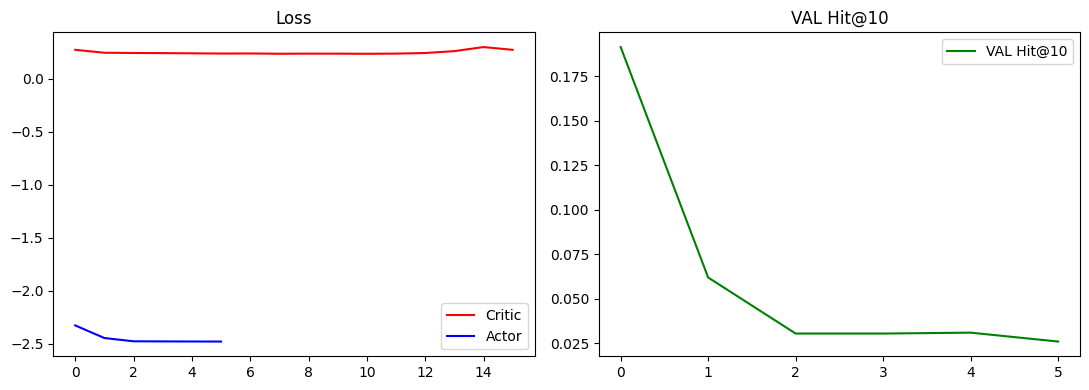

[+] Đã lưu BEST actor tại 'actor_trained.pth'
[+] Train xong. BEST actor lưu tại 'actor_trained.pth'.


In [12]:
# ==========================================================
# CELL MASTER: SETUP + TRAIN (early stop) -> lưu BEST actor_trained.pth
# ==========================================================
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Device: {device}")

# Dữ liệu
test_data    = prepare_rl_test_data(RATING_FILE_PATH, max_seq_len=200)
val_data     = prepare_rl_val_data(RATING_FILE_PATH, max_seq_len=200)
offline_data = load_offline_data_custom(RATING_FILE_PATH, max_history_len=200, min_history_len=5)

# BERT4Rec gốc (đóng băng)
custom_bert_model = BERT4Rec(
    n_items=3707, max_seq_length=200, hidden_size=64,
    n_layers=2, n_heads=2, hidden_dropout_prob=0.1, attn_dropout_prob=0.1
).to(device)
custom_bert_model.load_state_dict(torch.load(MODEL_WEIGHT_PATH, map_location=device))
custom_bert_model.eval()
print("[+] Đã nạp BERT4Rec.")

# TRAIN với EARLY STOP (theo VAL Hit@10). encoder dùng lại cho phần đánh giá.
trained_actor, encoder = train_rl_only(
    offline_data, custom_bert_model, device,
    epochs=50, batch_size=256, alpha=2.5, beta=0.05,
    val_data=val_data, patience=5, val_subsample=2000
)
print("[+] Train xong. BEST actor lưu tại 'actor_trained.pth'.")

In [13]:
# ==========================================================
# SO SÁNH BERT vs RL — CONFIG + HELPERS
#   Lưu ý: khung này chấm bằng COSINE (như file bạn đưa) -> so NỘI BỘ
#   BERT-state vs RL công bằng. KHÔNG so trực tiếp số paper (paper dùng
#   dot+bias + negative theo popularity).
# ==========================================================
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

HIDDEN_SIZE   = 64
N_ITEMS       = 3706      # số phim thật: id 1..3706 (embedding [3708,H]: 0=pad, 3707=mask)
ACTOR_BETA    = 0.05      # PHẢI khớp beta lúc train
SEED          = 42
SAMPLED_NEG   = 100
SAMPLED_USERS = 2000      # số user cho giao thức sampled (đặt None = tất cả)

RL_CKPTS = {
    "RL (TD3+BC)": "actor_trained.pth",
}


@torch.no_grad()
def compute_actions(encoder, actor, data, device, batch_size=256):
    """data: list dict có key 'history'. Trả tensor [N, H].
       actor=None -> baseline BERT: action = normalize(state)."""
    encoder.eval()
    outs = []
    for i in range(0, len(data), batch_size):
        hb = [s["history"] for s in data[i:i + batch_size]]
        st = encoder.get_state(hb, device=device)          # [b, H]
        st = F.normalize(st, p=2, dim=-1)                  # state chuẩn hoá (như lúc train)
        a  = st if actor is None else actor(st)            # actor tự normalize output
        outs.append(a)
    return torch.cat(outs, dim=0)


@torch.no_grad()
def eval_full(actions, targets, item_emb_norm, ks=(1, 5, 10)):
    """Full-rank trên N_ITEMS phim. targets: id 1..N_ITEMS. item_emb_norm: [N_ITEMS, H]."""
    a = F.normalize(actions, p=2, dim=-1)
    metrics = {f"Hit@{k}": 0.0 for k in ks}
    metrics.update({f"NDCG@{k}": 0.0 for k in ks})
    Nq      = a.shape[0]
    tgt_col = (targets - 1).to(a.device)                  # id -> cột (item id j ở hàng j-1)
    bs = 512
    for i in range(0, Nq, bs):
        sc  = a[i:i + bs] @ item_emb_norm.T               # [b, N_ITEMS]
        tg  = tgt_col[i:i + bs]
        tsc = sc.gather(1, tg.unsqueeze(1))               # điểm của target [b,1]
        ranks = (sc > tsc).sum(dim=1)                      # rank 0-indexed
        for k in ks:
            hit = ranks < k
            metrics[f"Hit@{k}"]  += hit.sum().item()
            metrics[f"NDCG@{k}"] += (1.0 / torch.log2(ranks.float() + 2.0))[hit].sum().item()
    for kk in metrics:
        metrics[kk] /= Nq
    return metrics, N_ITEMS


@torch.no_grad()
def eval_sampled(actions, data, all_emb, device, ks=(1, 5, 10)):
    """1 target + SAMPLED_NEG negatives (uniform, seed cố định), trên SAMPLED_USERS user."""
    g    = random.Random(SEED)
    idxs = list(range(len(data)))
    if SAMPLED_USERS is not None and len(idxs) > SAMPLED_USERS:
        idxs = g.sample(idxs, SAMPLED_USERS)

    emb_norm = F.normalize(all_emb, p=2, dim=-1)          # index trực tiếp theo id
    a        = F.normalize(actions, p=2, dim=-1)
    metrics  = {f"Hit@{k}": 0.0 for k in ks}
    metrics.update({f"NDCG@{k}": 0.0 for k in ks})

    for n in idxs:
        tid  = data[n]["target"]
        negs = set()
        while len(negs) < SAMPLED_NEG:
            x = g.randint(1, N_ITEMS)
            if x != tid:
                negs.add(x)
        cand = torch.tensor([tid] + list(negs), dtype=torch.long, device=device)
        sc   = (a[n].unsqueeze(0) @ emb_norm[cand].T)[0]  # [1+NEG]; index 0 = target
        rank = (sc > sc[0]).sum().item()
        for k in ks:
            if rank < k:
                metrics[f"Hit@{k}"]  += 1.0
                metrics[f"NDCG@{k}"] += 1.0 / np.log2(rank + 2)

    M = len(idxs)
    for kk in metrics:
        metrics[kk] /= M
    return metrics, M

print("[+] Helpers sẵn sàng: compute_actions / eval_full / eval_sampled")

[+] Helpers sẵn sàng: compute_actions / eval_full / eval_sampled


In [14]:
# ==========================================================
# XÂY DỰNG TEST SETS (leave-one-out item cuối)
#   leave_one_out : target = item cuối (mọi rating)
#   liked(r>=4)   : chỉ user có item cuối rating >= 4 (kiểm tra RL có ưu tiên phim hay)
# ==========================================================
def build_test_sets(rating_file_path, max_seq_len=200):
    cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
    ratings = pd.read_csv(rating_file_path, sep='::', engine='python', names=cols)
    ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)

    raw_ids  = sorted(ratings['MovieID'].unique())
    movie2id = {r: i + 1 for i, r in enumerate(raw_ids)}
    ratings['enc'] = ratings['MovieID'].map(movie2id)
    ratings['pair'] = list(zip(ratings['enc'], ratings['Rating']))
    seqs = ratings.groupby('UserID')['pair'].apply(list).to_dict()

    los, liked = [], []
    for _, seq in seqs.items():
        if len(seq) < 5:
            continue
        history = [m for m, r in seq[:-1]][-max_seq_len:]
        tid, trat = seq[-1]
        sample = {"history": history, "target": int(tid), "rating": float(trat)}
        los.append(sample)
        if trat >= 4.0:
            liked.append(sample)

    print(f"[+] test_sets: leave_one_out={len(los)} | liked(r>=4)={len(liked)}")
    return {"leave_one_out": los, "liked(r>=4)": liked}

test_sets = build_test_sets(RATING_FILE_PATH, max_seq_len=200)

[+] test_sets: leave_one_out=6040 | liked(r>=4)=3563


In [15]:
# ==========================================================
# BẢNG SO SÁNH: BERT (no RL) vs RL  —  full-rank & sampled
# ==========================================================
all_emb       = encoder.bert.item_embedding.weight.detach()      # [N+1, H]
item_emb_norm = F.normalize(all_emb[1:N_ITEMS + 1], p=2, dim=-1)  # [N, H] cho full-rank

# Nap san cac Actor (+ baseline None)
models = {"BERT (no RL)": None}
for name, path in RL_CKPTS.items():
    if not os.path.exists(path):
        print(f"[!] Bo qua {name}: khong thay '{path}'"); continue
    a = Actor(HIDDEN_SIZE, HIDDEN_SIZE, beta=ACTOR_BETA).to(device)
    a.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    a.eval(); models[name] = a

# results[test_set][model][proto] = metrics
results = {ts: {} for ts in test_sets}
for ts_name, data in test_sets.items():
    targets = torch.tensor([s["target"] for s in data], dtype=torch.long, device=device)
    for m_name, actor in models.items():
        actions = compute_actions(encoder, actor, data, device)   # tinh 1 lan
        m_full, n_full = eval_full(actions, targets, item_emb_norm)
        m_samp, n_samp = eval_sampled(actions, data, all_emb, device)
        results[ts_name][m_name] = {"full": m_full, "sampled": m_samp}
        print(f"[{ts_name} | {m_name}] full(N={n_full:,})  sampled(N={n_samp})  done")
print("Xong.")

COLS = ["Hit@1", "Hit@5", "Hit@10", "NDCG@1", "NDCG@5", "NDCG@10"]

def print_table(results, proto):
    width = 18 + 14 + len(COLS) * 10
    title = (f"sampled: 1 target + {SAMPLED_NEG} neg, {SAMPLED_USERS} users, seed={SEED}"
             if proto == "sampled" else f"full catalog = {N_ITEMS} items")
    print("\n" + "=" * width)
    print(f"GIAO THUC: {proto.upper()}   ({title})")
    print("=" * width)
    print(f"{'Test set':<18}{'Model':<14}" + "".join(f"{c:>10}" for c in COLS))
    print("-" * width)
    for ts_name, per_model in results.items():
        for m_name, r in per_model.items():
            m = r[proto]
            print(f"{ts_name:<18}{m_name:<14}" + "".join(f"{m[c]:>10.4f}" for c in COLS))
        print("-" * width)
    print("=" * width)

print_table(results, "full")
print_table(results, "sampled")

[leave_one_out | BERT (no RL)] full(N=3,706)  sampled(N=2000)  done


[leave_one_out | RL (TD3+BC)] full(N=3,706)  sampled(N=2000)  done


[liked(r>=4) | BERT (no RL)] full(N=3,706)  sampled(N=2000)  done


[liked(r>=4) | RL (TD3+BC)] full(N=3,706)  sampled(N=2000)  done
Xong.

GIAO THUC: FULL   (full catalog = 3706 items)
Test set          Model              Hit@1     Hit@5    Hit@10    NDCG@1    NDCG@5   NDCG@10
--------------------------------------------------------------------------------------------
leave_one_out     BERT (no RL)      0.0267    0.1126    0.1932    0.0267    0.0689    0.0947
leave_one_out     RL (TD3+BC)       0.0265    0.1093    0.1911    0.0265    0.0672    0.0932
--------------------------------------------------------------------------------------------
liked(r>=4)       BERT (no RL)      0.0261    0.1069    0.1847    0.0261    0.0660    0.0908
liked(r>=4)       RL (TD3+BC)       0.0267    0.1055    0.1838    0.0267    0.0653    0.0901
--------------------------------------------------------------------------------------------

GIAO THUC: SAMPLED   (sampled: 1 target + 100 neg, 2000 users, seed=42)
Test set          Model              Hit@1     Hit@5    Hit@10   

In [16]:
# ==========================================================
# SO SÁNH VỚI PAPER (BERT4Rec, ML-1m)
#   GIAO THỨC PAPER: leave-one-out + 100 neg theo POPULARITY + dot+bias
#   -> đo BERT thuần (và RL) đúng chuẩn để đối chiếu số paper.
# ==========================================================
from collections import Counter

# Số paper (Sun et al. 2019, ML-1m)
PAPER_ML1M = {"HR@1": 0.2863, "HR@5": 0.5876, "HR@10": 0.6970,
              "NDCG@5": 0.4454, "NDCG@10": 0.4818, "MRR": 0.4254}

def _item_popularity(rating_file_path):
    seqs = _encoded_user_seqs(rating_file_path)
    pop = Counter()
    for s in seqs.values():
        pop.update(s)
    ids  = np.array(sorted(pop.keys()))
    prob = np.array([pop[i] for i in ids], dtype=np.float64)
    prob /= prob.sum()
    return ids, prob

@torch.no_grad()
def evaluate_vs_paper(bert, encoder, test_data, device, actor=None, n_neg=100, seed=42):
    """Chấm theo chuẩn paper: dot+bias, 100 neg popularity, loại item user đã xem.
       actor=None -> BERT thuần (state THÔ, không normalize)."""
    bert.eval()
    item_emb = bert.item_embedding.weight[:bert.n_items]   # [n_items, H]  (idx 0..n_items-1)
    bias     = bert.output_bias                             # [n_items]
    pop_ids, pop_prob = _item_popularity(RATING_FILE_PATH)
    rng = np.random.RandomState(seed)

    # States: BERT dùng state THÔ; RL dùng action = actor(normalize(state))
    states = []
    for i in range(0, len(test_data), 256):
        hb = [s["history"] for s in test_data[i:i + 256]]
        st = encoder.get_state(hb, device=device)           # raw
        if actor is not None:
            st = actor(F.normalize(st, p=2, dim=-1))
        states.append(st)
    states = torch.cat(states)

    ks = (1, 5, 10)
    M = {f"HR@{k}": 0.0 for k in ks}
    M.update({f"NDCG@{k}": 0.0 for k in (5, 10)})
    M["MRR"] = 0.0

    for n, s in enumerate(test_data):
        tid  = s["target"]
        seen = set(s["history"]); seen.add(tid)
        negs = []
        while len(negs) < n_neg:
            draw = rng.choice(pop_ids, size=n_neg * 2, p=pop_prob)
            for c in draw:
                c = int(c)
                if c not in seen:
                    negs.append(c); seen.add(c)
                    if len(negs) >= n_neg: break
        cand = torch.tensor([tid] + negs, dtype=torch.long, device=device)
        sc   = states[n] @ item_emb[cand].T + bias[cand]    # dot + bias, [101]
        rank = (sc > sc[0]).sum().item()                     # vị trí target (0-indexed)
        M["MRR"] += 1.0 / (rank + 1)
        for k in ks:
            if rank < k:
                M[f"HR@{k}"] += 1.0
        for k in (5, 10):
            if rank < k:
                M[f"NDCG@{k}"] += 1.0 / np.log2(rank + 2)
    T = len(test_data)
    for kk in M:
        M[kk] /= T
    return M

# ----- CHẠY: BERT thuần vs RL, đối chiếu paper -----
print("=" * 70)
print("SO SÁNH VỚI PAPER — ML-1m (leave-one-out, 100 neg POPULARITY, dot+bias)")
print(f"(pool item của bạn = {custom_bert_model.n_items} ; paper = 3416 -> lệch nhẹ là bình thường)")
print("=" * 70)
res_bert = evaluate_vs_paper(custom_bert_model, encoder, test_sets["leave_one_out"], device, actor=None)
res_rl   = evaluate_vs_paper(custom_bert_model, encoder, test_sets["leave_one_out"], device, actor=trained_actor)

COLS2 = ["HR@1", "HR@5", "HR@10", "NDCG@5", "NDCG@10", "MRR"]
def _row(name, m): print(f"{name:<18}" + "".join(f"{m[c]:>9.4f}" for c in COLS2))
print(f"{'Model':<18}" + "".join(f"{c:>9}" for c in COLS2))
print("-" * (18 + 9 * len(COLS2)))
_row("Paper BERT4Rec", PAPER_ML1M)
_row("BERT (cua ban)", res_bert)
_row("RL (TD3+BC)",   res_rl)
print("=" * 70)

SO SÁNH VỚI PAPER — ML-1m (leave-one-out, 100 neg POPULARITY, dot+bias)
(pool item của bạn = 3707 ; paper = 3416 -> lệch nhẹ là bình thường)


Model                  HR@1     HR@5    HR@10   NDCG@5  NDCG@10      MRR
------------------------------------------------------------------------
Paper BERT4Rec       0.2863   0.5876   0.6970   0.4454   0.4818   0.4254
BERT (cua ban)       0.2775   0.5647   0.6785   0.4290   0.4658   0.4115
RL (TD3+BC)          0.1055   0.3411   0.5058   0.2251   0.2783   0.2289
